In [2]:
# !pip install PyMySQL

In [1]:
import pymysql.cursors

In [64]:
# Connect to the database
connection = pymysql.connect(host='localhost',
                             user='root',
                             password='1234',
                             database='sql_exercises',
                             charset='utf8mb4',
                             cursorclass=pymysql.cursors.DictCursor)

In [3]:
with connection:
    with connection.cursor() as cursor:
        # Create a new record
        sql = "Select * from employees"
        cursor.execute(sql)
        data = cursor.fetchall()
        print(data)

[{'id': 1, 'name': 'Bob Dylan', 'age': 83, 'salary': 10000}, {'id': 2, 'name': 'Chris Martin', 'age': 53, 'salary': 4000}, {'id': 3, 'name': 'Alice patt', 'age': 35, 'salary': 3000}, {'id': 4, 'name': 'Mark Hamill', 'age': 45, 'salary': 1000}]


In [4]:
import pandas as pd

In [5]:
df = pd.DataFrame(data)

In [6]:
df

,id,name,age,salary
0,1,Bob Dylan,83,10000
1,2,Chris Martin,53,4000
2,3,Alice patt,35,3000
3,4,Mark Hamill,45,1000


In [7]:
import matplotlib.pyplot as plt

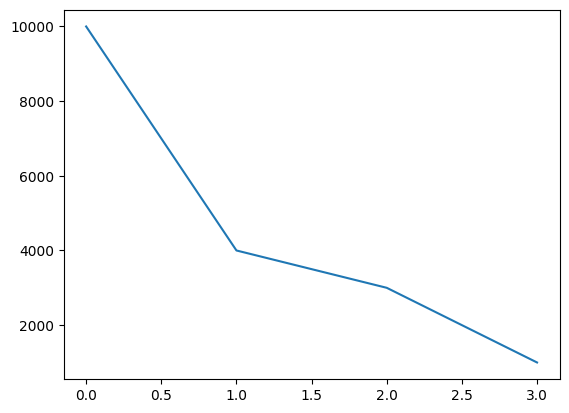

In [9]:
plt.plot(list(range(len(df))),df['salary'])
plt.show()

In [16]:
with connection:
    with connection.cursor() as cursor:
        # Create a new record
        sql = "Select avg(salary) as avg_salary from employees"
        cursor.execute(sql)
        data = cursor.fetchall()
        print(data)

[{'avg_salary': Decimal('4500.0000')}]


In [20]:
temp = int(data[0]['avg_salary'])

In [22]:
temp

4500

In [42]:
import seaborn as sns
import numpy as np

In [26]:
dataset = sns.load_dataset('titanic')

In [27]:
dataset

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [28]:
ids = dataset.columns

In [46]:
temp_data = np.array(dataset)

In [51]:
def foo(arr,ids,index):
    dict1 = {}
    dict1['id'] = index
    for i,id in zip(arr,ids):
        dict1[id] = i
    return dict1

In [52]:
dataset_dict = [foo(i,ids, index) for index,i in enumerate(temp_data)]

In [54]:
dataset_dict[0]

{'id': 0,
 'survived': 0,
 'pclass': 3,
 'sex': 'male',
 'age': 22.0,
 'sibsp': 1,
 'parch': 0,
 'fare': 7.25,
 'embarked': 'S',
 'class': 'Third',
 'who': 'man',
 'adult_male': True,
 'deck': nan,
 'embark_town': 'Southampton',
 'alive': 'no',
 'alone': False}

In [59]:
with connection:
    with connection.cursor() as cursor:
        # Create a new record
        sql = "create table titanic(id INT PRIMARY KEY,survived INT(1),pclass INT(1),sex VARCHAR(7),age INT,sibsp INT,parch INT,fare FLOAT,embarked VARCHAR(2),class VARCHAR(10),who VARCHAR(10),adult_male VARCHAR(10),deck VARCHAR(10),embark_town VARCHAR(100),alive VARCHAR(10),alone VARCHAR(10))"
        cursor.execute(sql)

    connection.commit()

In [65]:
with connection:
    with connection.cursor() as cursor:
        record = dataset_dict[0]
        sql = """INSERT INTO `titanic` (`id`, `survived`, `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, `class`, `who`, `adult_male``deck`, `embark_town`, `alive`, `alone`) 
                 VALUES (%(id)s, %(survived)s, %(pclass)s, %(sex)s, %(age)s, %(sibsp)s, %(parch)s, %(fare)s, %(embarked)s, %(class)s, %(who)s, %(adult_male)s, %(deck)s, %(embark_town)s, %(alive)s, %(alone)s)"""
        cursor.execute(sql, record)
    connection.commit()

ProgrammingError: nan can not be used with MySQL